In [1]:
# Import libraries 

import pandas as pd 
import matplotlib.pyplot as plt 
import requests 

import nltk 
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from collections import Counter 
import re, os 

In [2]:
# Calling API 

API_key = '16dc3ec0156243cc9ca1fa7dd283b6db' 
query = 'AI' 

In [3]:
url = f'https://newsapi.org/v2/everything?q={query}&from=2025-05-05&to=2025-06-04&language=en&apiKey={API_key}'

response = requests.get(url)
articles = response.json()['articles']

In [4]:
# Collect articles and make them a list 

texts = [a['title'] + ' ' + (a['description'] or '') for a in articles]  

In [5]:
# Function to clean the news articles  

def clean_text(texts): 
    texts = re.sub(r'[^a-zA-Z ]', '', texts) 
    return texts.lower()

In [6]:
# Function to remove plural 

def basic_lemmatize(word):
    if word.endswith('s') and not word.endswith('ss'):
        return word[:-1]
    return word

In [7]:
# Make the list of articles after cleaning 

cleaned = [clean_text(t) for t in texts] 

In [8]:
# Combine all the cleaned words  

all_words = " ".join(cleaned).split() 

In [9]:
print(all_words[:20])

['google', 'is', 'stuffing', 'even', 'more', 'ads', 'into', 'its', 'ai', 'results', 'googles', 'ai', 'search', 'results', 'are', 'about', 'to', 'get', 'even', 'more']


In [10]:
nltk.download('stopwords', download_dir=r"C:\Users\lg2021\AppData\Roaming\nltk_data")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lg2021\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
print(stopwords.words('english')[:10]) 

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


In [12]:
# Create STOPWORDS 

nltk.data.path.append(r'C:\Users\lg2021\AppData\Roaming\nltk_data') 

stopwords = set(stopwords.words('english'))

custom_stopwords = {"will", "users", "announced", "your", "about", 'also', 'one', 'could', 'even'}
all_stopwords = stopwords.union(custom_stopwords)


In [13]:
# List of words that exclude stopwords 

filtered = [w for w in all_words if w not in all_stopwords and len(w) > 3]

# List of words that exclude lemmatizer 

final_word  = [basic_lemmatize(w) for w in filtered]


In [14]:
# Count the frequency of words that are more than 3 letters 

word_freq = Counter([w for w in final_word if len(w) > 3])


In [15]:
print(word_freq.most_common(10))

[('google', 62), ('company', 21), ('microsoft', 18), ('openai', 17), ('gemini', 17), ('feature', 16), ('model', 16), ('search', 12), ('meta', 12), ('android', 12)]


In [16]:
output_dir = r"C:\Users\lg2021\OneDrive\Job\Data\Python\figures"
os.makedirs(output_dir, exist_ok=True) 

file_path = os.path.join(output_dir, "wordcloud.png")

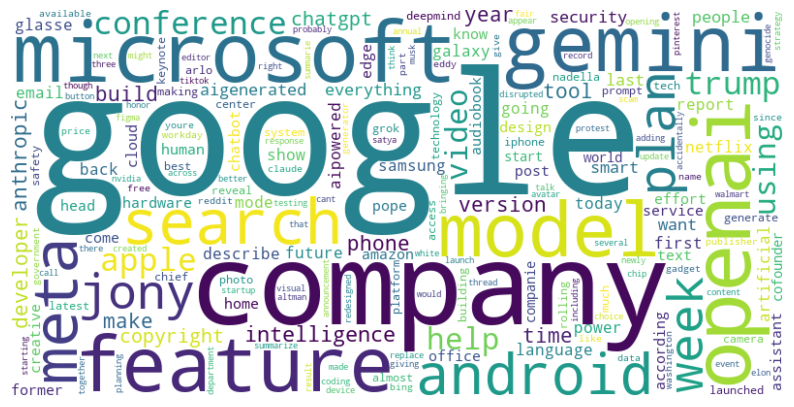

In [17]:
# Visualise word count 

wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq) 

plt.figure(figsize=(10,6)) 

plt.imshow(wc, interpolation='bilinear')
plt.axis("off")

plt.savefig(file_path)
plt.show()